In [2]:

# INSTRUCTIONS: Run each CELL one by one in Jupyter Notebook
# Each cell is fully self-contained — no dependencies!
# Just change the CSV path in EACH cell if needed.
# ============================================================


# ============================================================
# CELL 0 — RUN THIS FIRST (One time setup)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

# ── Load & Prepare Data ──────────────────────────────────────
df = pd.read_csv('SampleSuperstore.csv', encoding='latin1')

df['Profit_Margin']    = round((df['Profit'] / df['Sales']) * 100, 2)
df['Revenue_Per_Unit'] = round(df['Sales'] / df['Quantity'], 2)
df['Is_Loss']          = df['Profit'] < 0
df['Discount_Bracket'] = pd.cut(
    df['Discount'],
    bins=[-0.01, 0, 0.2, 0.4, 0.6, 0.8],
    labels=['No Discount', '1-20%', '21-40%', '41-60%', '61-80%']
)

print("✅ Data ready! Shape:", df.shape)
print("✅ All libraries imported!")


✅ Data ready! Shape: (9994, 17)
✅ All libraries imported!


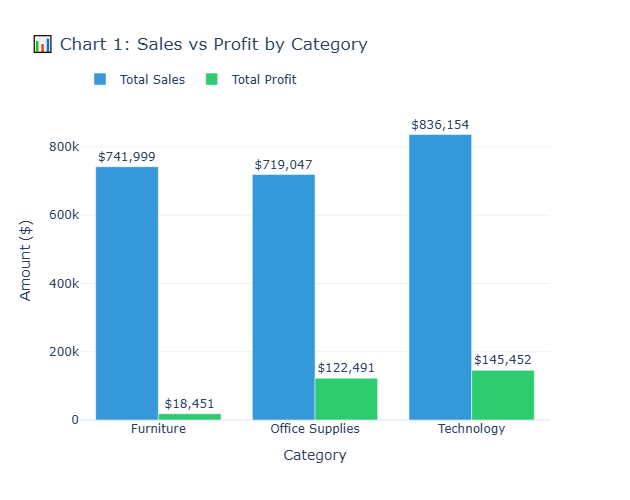

✅ Chart 1 done!
saved sucessfully


In [8]:
# ============================================================
# CELL 1 — CHART 1: Revenue & Profit by Category (Bar Chart)
# ============================================================

import pandas as pd
import plotly.graph_objects as go

df = pd.read_csv('SampleSuperstore.csv', encoding='latin1')

category_summary = df.groupby('Category').agg(
    Total_Sales  = ('Sales', 'sum'),
    Total_Profit = ('Profit', 'sum')
).reset_index()

fig = go.Figure()

fig.add_trace(go.Bar(
    name='Total Sales',
    x=category_summary['Category'],
    y=category_summary['Total_Sales'],
    marker_color='#3498db',
    text=category_summary['Total_Sales'].map('${:,.0f}'.format),
    textposition='outside'
))

fig.add_trace(go.Bar(
    name='Total Profit',
    x=category_summary['Category'],
    y=category_summary['Total_Profit'],
    marker_color='#2ecc71',
    text=category_summary['Total_Profit'].map('${:,.0f}'.format),
    textposition='outside'
))

fig.update_layout(
    title='📊 Chart 1: Sales vs Profit by Category',
    barmode='group',
    xaxis_title='Category',
    yaxis_title='Amount ($)',
    template='plotly_white',
    height=500,
    legend=dict(orientation='h', yanchor='bottom', y=1.02)
)

fig.show()
print("✅ Chart 1 done!")
fig.write_html('visuals/chart1_sales_vs_profit.html')
print("saved sucessfully")



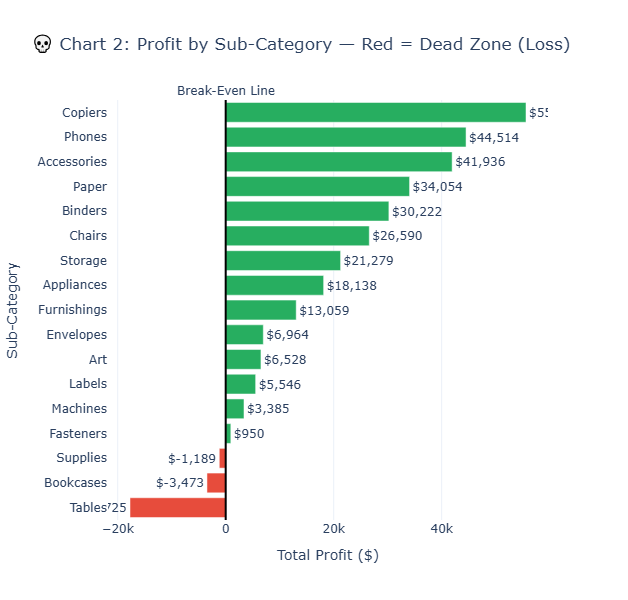

✅ Chart 2 done! — Tables, Bookcases, Supplies are DEAD ZONES
saved successfully


In [9]:
# ============================================================
# CELL 2 — CHART 2: Profit by Sub-Category (Dead Zone Chart)
# ============================================================

import pandas as pd
import plotly.graph_objects as go

df = pd.read_csv('SampleSuperstore.csv', encoding='latin1')

sub_profit = df.groupby('Sub-Category')['Profit'].sum().reset_index()
sub_profit = sub_profit.sort_values('Profit')
sub_profit.columns = ['Sub_Category', 'Total_Profit']

# Color: Red if loss, Green if profit
colors = ['#e74c3c' if x < 0 else '#27ae60' for x in sub_profit['Total_Profit']]

fig = go.Figure(go.Bar(
    x=sub_profit['Total_Profit'],
    y=sub_profit['Sub_Category'],
    orientation='h',
    marker_color=colors,
    text=sub_profit['Total_Profit'].map('${:,.0f}'.format),
    textposition='outside'
))

fig.add_vline(
    x=0,
    line_color='black',
    line_width=2,
    annotation_text='Break-Even Line',
    annotation_position='top'
)

fig.update_layout(
    title='💀 Chart 2: Profit by Sub-Category — Red = Dead Zone (Loss)',
    xaxis_title='Total Profit ($)',
    yaxis_title='Sub-Category',
    template='plotly_white',
    height=600
)

fig.show()
print("✅ Chart 2 done! — Tables, Bookcases, Supplies are DEAD ZONES")
fig.write_html('visuals/chart2_dead_zone_profit.html')
print('saved successfully')

✅ Pivot table created! Shape: (17, 4)
Region         Central      East     South      West
Sub-Category                                        
Accessories    7251.63  11195.86   7004.54  16483.63
Appliances    -2638.62   8391.41   4123.94   8261.27
Art            1195.16   1899.94   1058.59   2374.10
Binders       -1043.64  11267.93   3900.66  16096.80
Bookcases     -1997.90  -1167.63   1339.49  -1646.51
Chairs         6592.72   9357.77   6612.09   4027.58
Copiers       15608.84  17022.84   3658.91  19327.24
Envelopes      1777.53   1812.41   1465.48   1908.76
Fasteners       236.62    263.99    173.72    275.19
Furnishings   -3906.22   5881.41   3442.68   7641.27
Labels         1073.08   1129.28   1040.77   2303.12
Machines      -1486.07   6928.64  -1438.89   -618.93
Paper          6971.90   9015.37   5947.06  12119.24
Phones        12321.03  12314.69  10767.28   9110.74
Storage        1969.84   8389.37   2274.30   8645.32
Supplies       -661.89  -1155.14      1.88    626.05
Tables  

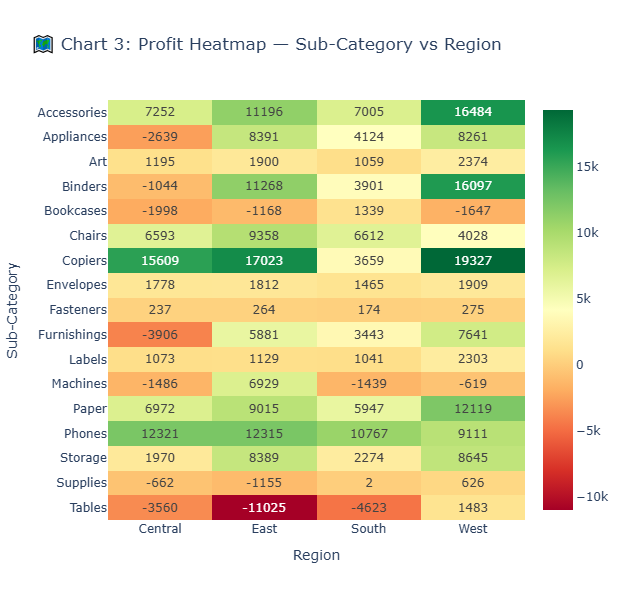

✅ Chart 3 done!
saved successfully


In [10]:
# ============================================================
# CELL 3 — CHART 3: Profit Heatmap (Sub-Category vs Region)
# ============================================================

import pandas as pd
import plotly.express as px

df = pd.read_csv('SampleSuperstore.csv', encoding='latin1')

# Create pivot table
pivot = df.pivot_table(
    values='Profit',
    index='Sub-Category',
    columns='Region',
    aggfunc='sum'
).round(2)

print("✅ Pivot table created! Shape:", pivot.shape)
print(pivot)

fig = px.imshow(
    pivot,
    color_continuous_scale='RdYlGn',
    title='🗺️ Chart 3: Profit Heatmap — Sub-Category vs Region',
    text_auto='.0f',
    aspect='auto'
)

fig.update_layout(
    height=600,
    xaxis_title='Region',
    yaxis_title='Sub-Category'
)

fig.show()
print("✅ Chart 3 done!")
fig.write_html('visuals/chart3_heatmap.html')
print("saved successfully")



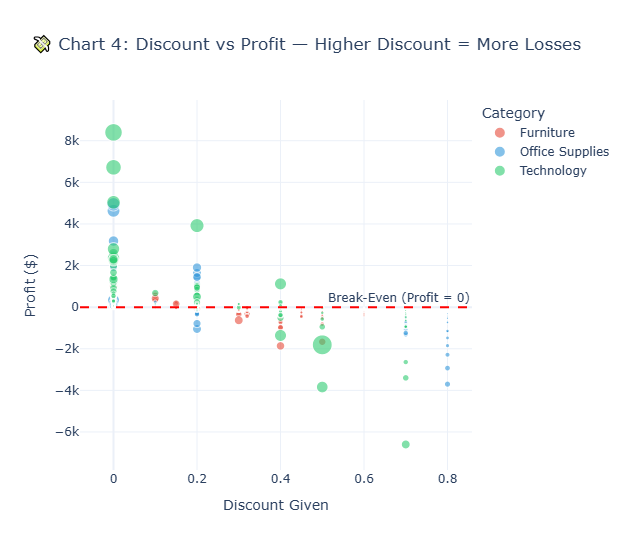

✅ Chart 4 done!
saved!


In [11]:
# ============================================================
# CELL 4 — CHART 4: Discount vs Profit Scatter Plot
# ============================================================

import pandas as pd
import plotly.express as px

df = pd.read_csv('SampleSuperstore.csv', encoding='latin1')

fig = px.scatter(
    df,
    x='Discount',
    y='Profit',
    color='Category',
    size='Sales',
    hover_data=['Sub-Category', 'Region', 'State'],
    title='💸 Chart 4: Discount vs Profit — Higher Discount = More Losses',
    color_discrete_sequence=['#e74c3c', '#3498db', '#2ecc71'],
    opacity=0.6
)

# Break-even line
fig.add_hline(
    y=0,
    line_dash='dash',
    line_color='red',
    line_width=2,
    annotation_text='Break-Even (Profit = 0)',
    annotation_position='top right'
)

fig.update_layout(
    xaxis_title='Discount Given',
    yaxis_title='Profit ($)',
    template='plotly_white',
    height=550
)

fig.show()
print("✅ Chart 4 done!")
fig.write_html('visuals/chart4_discount_scatter.html')
print("saved!")



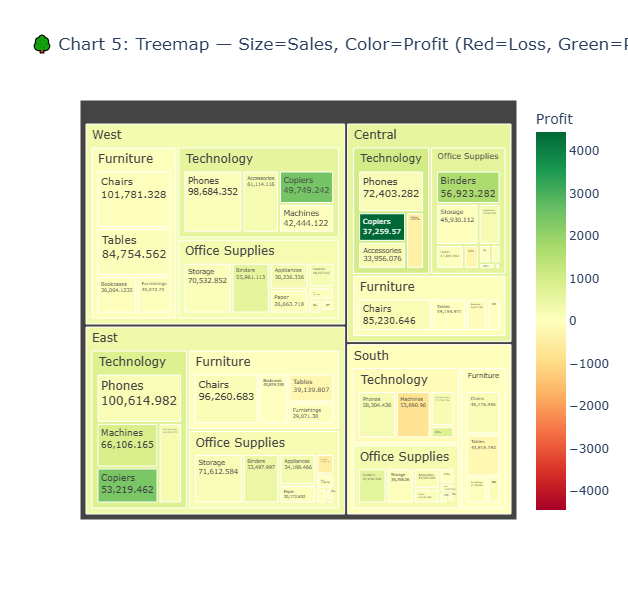

✅ Chart 5 done!
saved!


In [12]:
# ============================================================
# CELL 5 — CHART 5: Sales Treemap (Region > Category > Sub)
# ============================================================

import pandas as pd
import plotly.express as px

df = pd.read_csv('SampleSuperstore.csv', encoding='latin1')

fig = px.treemap(
    df,
    path=['Region', 'Category', 'Sub-Category'],
    values='Sales',
    color='Profit',
    color_continuous_scale='RdYlGn',
    color_continuous_midpoint=0,
    title='🌳 Chart 5: Treemap — Size=Sales, Color=Profit (Red=Loss, Green=Profit)'
)

fig.update_layout(height=600)
fig.update_traces(textinfo='label+value')

fig.show()
print("✅ Chart 5 done!")
fig.write_html('visuals/chart5_treemap.html')
print("saved!")



🎯 Dead Zone Results:
   Sub-Category  Total_Profit  Performance_Score              Zone_Tag
3        Tables   -17725.4811              0.139  💀 Critical Dead Zone
0     Bookcases    -3472.5560              0.152  💀 Critical Dead Zone
15     Machines     3384.7569              0.221     🟡 Underperforming
12     Supplies    -1189.0995              0.244  💀 Critical Dead Zone
4    Appliances    18138.0054              0.275     🟡 Underperforming
8     Fasteners      949.5182              0.301     🟡 Underperforming
5           Art     6527.7870              0.384     🟡 Underperforming
7     Envelopes     6964.1767              0.389     🟡 Underperforming
9        Labels     5546.2540              0.399     🟡 Underperforming
2   Furnishings    13059.1436              0.413     🟡 Underperforming
6       Binders    30221.7633              0.432     🟡 Underperforming
11      Storage    21278.8264              0.544             🟢 Average
1        Chairs    26590.1663              0.579        

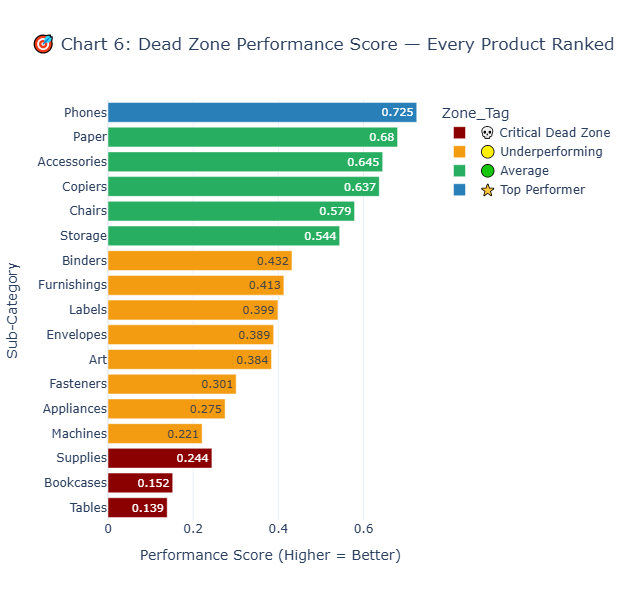

✅ Chart 6 done!
saved!


In [13]:
# ============================================================
# CELL 6 — CHART 6: Dead Zone Performance Score
# ============================================================

import pandas as pd
import plotly.express as px
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv('SampleSuperstore.csv', encoding='latin1')
df['Profit_Margin'] = round((df['Profit'] / df['Sales']) * 100, 2)
df['Is_Loss']       = df['Profit'] < 0

# Build zone summary
zone_df = df.groupby(['Category', 'Sub-Category']).agg(
    Total_Sales   = ('Sales', 'sum'),
    Total_Profit  = ('Profit', 'sum'),
    Avg_Margin    = ('Profit_Margin', 'mean'),
    Avg_Discount  = ('Discount', 'mean'),
    Total_Qty     = ('Quantity', 'sum'),
    Orders        = ('Sales', 'count'),
    Loss_Orders   = ('Is_Loss', 'sum')
).reset_index()

zone_df['Loss_Rate'] = round(
    (zone_df['Loss_Orders'] / zone_df['Orders']) * 100, 1
)

# Scoring
scaler = MinMaxScaler()
zone_df[['S','P','M','Q']] = scaler.fit_transform(
    zone_df[['Total_Sales','Total_Profit','Avg_Margin','Total_Qty']]
)
zone_df['D'] = scaler.fit_transform(zone_df[['Avg_Discount']])

zone_df['Performance_Score'] = round(
    zone_df['S']*0.25 + zone_df['P']*0.35 +
    zone_df['M']*0.25 + zone_df['Q']*0.15 -
    zone_df['D']*0.1, 3
)

# Tagging
def tag(score, profit):
    if profit < 0:      return '💀 Critical Dead Zone'
    elif score < 0.2:   return '🔴 Dead Zone'
    elif score < 0.45:  return '🟡 Underperforming'
    elif score < 0.7:   return '🟢 Average'
    else:               return '⭐ Top Performer'

zone_df['Zone_Tag'] = zone_df.apply(
    lambda r: tag(r['Performance_Score'], r['Total_Profit']), axis=1
)

zone_df = zone_df.sort_values('Performance_Score')

print("🎯 Dead Zone Results:")
print(zone_df[['Sub-Category','Total_Profit','Performance_Score','Zone_Tag']].to_string())

color_map = {
    '💀 Critical Dead Zone': '#8B0000',
    '🔴 Dead Zone':          '#e74c3c',
    '🟡 Underperforming':    '#f39c12',
    '🟢 Average':            '#27ae60',
    '⭐ Top Performer':      '#2980b9'
}

fig = px.bar(
    zone_df,
    x='Performance_Score',
    y='Sub-Category',
    color='Zone_Tag',
    orientation='h',
    color_discrete_map=color_map,
    title='🎯 Chart 6: Dead Zone Performance Score — Every Product Ranked',
    text='Performance_Score',
    hover_data=['Category','Total_Profit','Loss_Rate']
)

fig.update_layout(
    xaxis_title='Performance Score (Higher = Better)',
    yaxis_title='Sub-Category',
    template='plotly_white',
    height=600,
    showlegend=True
)

fig.show()
print("✅ Chart 6 done!")
fig.write_html('visuals/chart6_performance_score.html')
print("saved!")


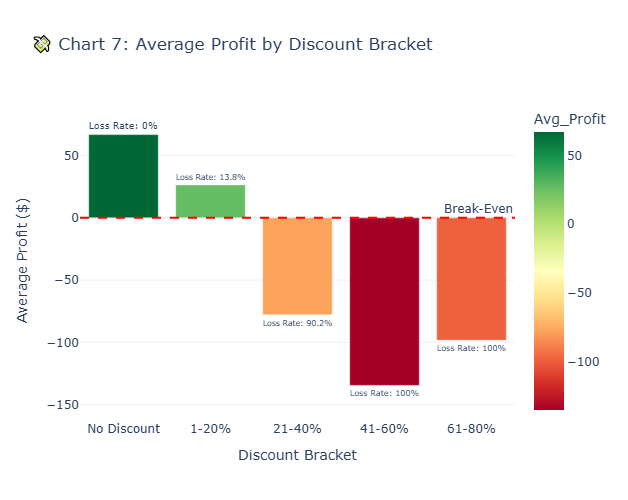

✅ Chart 7 done!
saved!


In [14]:
# ============================================================
# CELL 7 — CHART 7: Avg Profit by Discount Bracket
# ============================================================

import pandas as pd
import plotly.express as px

df = pd.read_csv('SampleSuperstore.csv', encoding='latin1')
df['Is_Loss'] = df['Profit'] < 0
df['Discount_Bracket'] = pd.cut(
    df['Discount'],
    bins=[-0.01, 0, 0.2, 0.4, 0.6, 0.8],
    labels=['No Discount', '1-20%', '21-40%', '41-60%', '61-80%']
)

disc_summary = df.groupby('Discount_Bracket', observed=True).agg(
    Avg_Profit = ('Profit', 'mean'),
    Loss_Rate  = ('Is_Loss', 'mean'),
    Orders     = ('Sales', 'count')
).reset_index()

disc_summary['Loss_Rate_Pct'] = round(disc_summary['Loss_Rate'] * 100, 1)

fig = px.bar(
    disc_summary,
    x='Discount_Bracket',
    y='Avg_Profit',
    color='Avg_Profit',
    color_continuous_scale='RdYlGn',
    text='Loss_Rate_Pct',
    title='💸 Chart 7: Average Profit by Discount Bracket'
)

fig.update_traces(texttemplate='Loss Rate: %{text}%', textposition='outside')
fig.add_hline(y=0, line_dash='dash', line_color='red',
              annotation_text='Break-Even', annotation_position='top right')

fig.update_layout(
    xaxis_title='Discount Bracket',
    yaxis_title='Average Profit ($)',
    template='plotly_white',
    height=500
)

fig.show()
print("✅ Chart 7 done!")
fig.write_html('visuals/chart7_discount_bracket.html')
print("saved!")

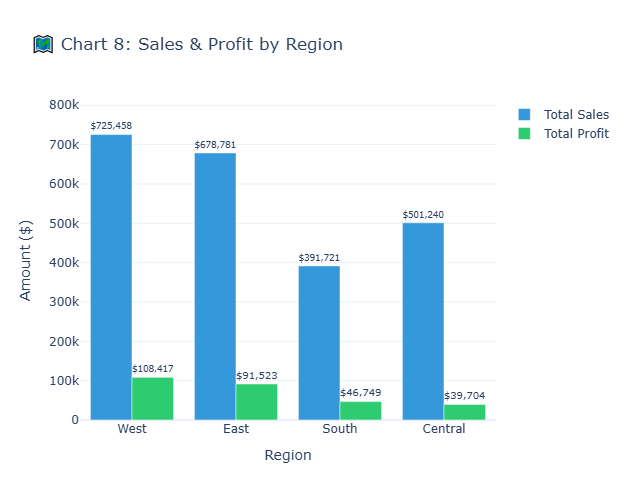

✅ Chart 8 done!
saved!


In [15]:
# CELL 8 — CHART 8: Region Sales & Profit (Grouped Bar)
# ============================================================

import pandas as pd
import plotly.graph_objects as go

df = pd.read_csv('SampleSuperstore.csv', encoding='latin1')

region_df = df.groupby('Region').agg(
    Total_Sales  = ('Sales', 'sum'),
    Total_Profit = ('Profit', 'sum'),
    Orders       = ('Sales', 'count')
).reset_index().sort_values('Total_Profit', ascending=False)

fig = go.Figure()

fig.add_trace(go.Bar(
    name='Total Sales',
    x=region_df['Region'],
    y=region_df['Total_Sales'],
    marker_color='#3498db',
    text=region_df['Total_Sales'].map('${:,.0f}'.format),
    textposition='outside'
))

fig.add_trace(go.Bar(
    name='Total Profit',
    x=region_df['Region'],
    y=region_df['Total_Profit'],
    marker_color='#2ecc71',
    text=region_df['Total_Profit'].map('${:,.0f}'.format),
    textposition='outside'
))

fig.update_layout(
    title='🗺️ Chart 8: Sales & Profit by Region',
    barmode='group',
    xaxis_title='Region',
    yaxis_title='Amount ($)',
    template='plotly_white',
    height=500
)

fig.show()
print("✅ Chart 8 done!")
fig.write_html('visuals/chart8_region.html')
print('saved!')



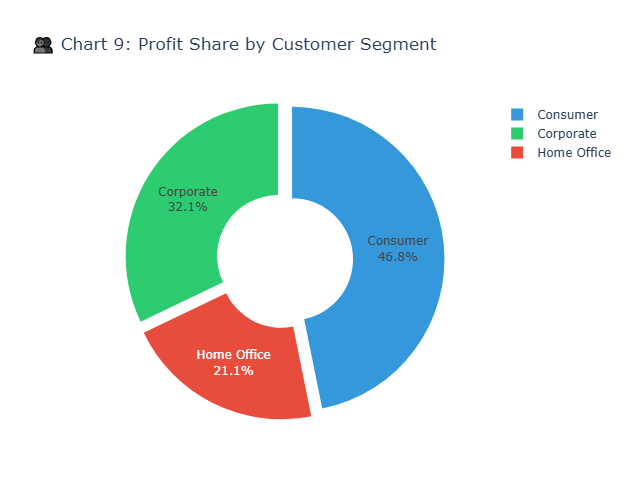

✅ Chart 9 done!
saved!


In [16]:
# ============================================================
# CELL 9 — CHART 9: Segment Profit Pie Chart
# ============================================================

import pandas as pd
import plotly.express as px

df = pd.read_csv('SampleSuperstore.csv', encoding='latin1')

segment_df = df.groupby('Segment').agg(
    Total_Sales  = ('Sales', 'sum'),
    Total_Profit = ('Profit', 'sum'),
    Orders       = ('Sales', 'count')
).reset_index()

fig = px.pie(
    segment_df,
    values='Total_Profit',
    names='Segment',
    title='👥 Chart 9: Profit Share by Customer Segment',
    color_discrete_sequence=['#3498db', '#2ecc71', '#e74c3c'],
    hole=0.4
)

fig.update_traces(
    textposition='inside',
    textinfo='percent+label',
    pull=[0.05, 0.05, 0.05]
)

fig.update_layout(height=500)
fig.show()
print("✅ Chart 9 done!")
fig.write_html('visuals/chart9_segment.html')
print('saved!')



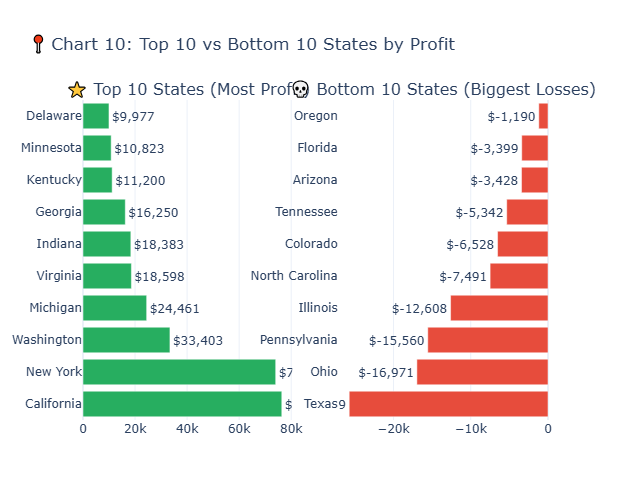

✅ Chart 10 done!

🎉 ALL 10 CHARTS COMPLETE!
saved!


In [17]:
# ============================================================
# CELL 10 — CHART 10: Top 10 & Bottom 10 States by Profit
# ============================================================

import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

df = pd.read_csv('SampleSuperstore.csv', encoding='latin1')

state_profit = df.groupby('State')['Profit'].sum().reset_index()
state_profit.columns = ['State', 'Total_Profit']

top10    = state_profit.nlargest(10, 'Total_Profit')
bottom10 = state_profit.nsmallest(10, 'Total_Profit')

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('⭐ Top 10 States (Most Profit)',
                    '💀 Bottom 10 States (Biggest Losses)')
)

fig.add_trace(go.Bar(
    x=top10['Total_Profit'],
    y=top10['State'],
    orientation='h',
    marker_color='#27ae60',
    name='Top 10',
    text=top10['Total_Profit'].map('${:,.0f}'.format),
    textposition='outside'
), row=1, col=1)

fig.add_trace(go.Bar(
    x=bottom10['Total_Profit'],
    y=bottom10['State'],
    orientation='h',
    marker_color='#e74c3c',
    name='Bottom 10',
    text=bottom10['Total_Profit'].map('${:,.0f}'.format),
    textposition='outside'
), row=1, col=2)

fig.update_layout(
    title='📍 Chart 10: Top 10 vs Bottom 10 States by Profit',
    template='plotly_white',
    height=500,
    showlegend=False
)

fig.show()
print("✅ Chart 10 done!")
print("\n🎉 ALL 10 CHARTS COMPLETE!")
fig.write_html('visuals/chart10_states.html')
print("saved!")
